Test: Multiline Voigt Raytrace
--------

Purpose
---------
This script verifies that the custom multiline Voigt wavelength distribution has been successfully integrated into the XICSRT ray tracing framework.

Objectives
---------
1. Configure a generic XICSRT source to use the new 'multiline_voigt' wavelength distribution
2. Generate a complete set of rays using the new wavelength sampler
3. Perform a full XICSRT raytrace from the source to detector
4. Confirm that every emitted ray is assigned a valid wavelength
5. Verify that the raytrace completes without errors
6. Plot the sampled wavelenth distribution and confirm that it reproduces the expected multiline Voigt spectrum

Notes
---------
This is an integration test only. The source is XicsrtSourceGeneric and does not represent a physical plasma

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import xicsrt
from xicsrt_multiline_voigt import voigt, multiline_voigt, multiline_voigt_cdf_tab, multiline_voigt_random

config = {}

config['general'] = {}
config['general']['number_of_iter'] = 1
config['general']['save_images'] = False
config['general']['save_results'] = False

config['sources'] = {}
config['sources']['source'] = {
    'class_name': 'XicsrtSourceGeneric',

    'origin': [0.0, 0.0, 0.0],
    'zaxis': [0.0, 0.0, 1.0],

    'intensity': 10000,
    'spatial_dist': 'uniform',
    'xsize': 0.0,
    'ysize': 0.0,
    'zsize': 0.0,

    'angular_dist': 'isotropic',
    'spread': 0.01,

    'wavelength_dist': 'multiline_voigt',

    'line_locations': np.array([3.9492, 3.9510, 3.9535]),
    'line_intensities': np.array([1.0, 0.5, 0.2]),
    'line_sigmas': np.array([0.0002, 0.0002, 0.0002]),
    'line_gammas': np.array([0.0001, 0.0001, 0.0001]),

    'multiline_gridsize': 10000,
    'multiline_cutoff': 1e-4,
}

config['optics'] = {}

config['optics']['detector'] = {
    'class_name': 'XicsrtOpticDetector',
    'origin': [0.0, 0.0, 1.0],
    'zaxis': [0.0, 0.0, -1.0],
    'xsize': 0.2,
    'ysize': 0.2,
    'pixel_size': 0.001,
}

results = xicsrt.raytrace(config)

 INFO:xicsrt: Starting run: 1 of 1
 INFO:xicsrt: Seeding np.random with None
 INFO:xicsrt: Starting iteration: 1 of 1



Rays Generated: 1.000e+04
Rays Detected:  1.000e+04
Efficiency:     1.000e+00 ± 1.0e-02 (100.00000%)



In [10]:
source_rays = results['found']['history']['source']
detector_rays = results['found']['history']['detector']

print("Generated rays:", len(source_rays['wavelength']))
print("Detector rays:", len(detector_rays['wavelength']))
print("Wavelength min/max:", np.min(source_rays['wavelength']), np.max(source_rays['wavelength']))

Generated rays: 10000
Detector rays: 10000
Wavelength min/max: 3.939264938552915 3.9633140389583152


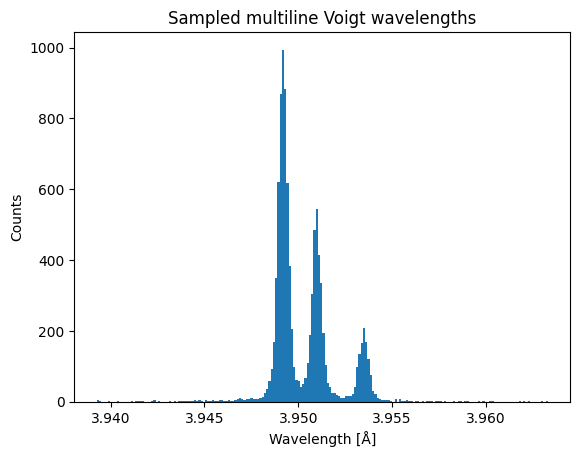

In [11]:
plt.hist(source_rays['wavelength'], bins=200)
plt.xlabel("Wavelength [Å]")
plt.ylabel("Counts")
plt.title("Sampled multiline Voigt wavelengths")
plt.show()